In [1]:
# Import Libraries

import numpy as np
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Load Both Datasets

df1 = pd.read_csv("Unemployment in India.csv")
df2 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

In [3]:
df1.shape

(768, 7)

In [4]:
df2.shape

(267, 9)

In [5]:
# Combine Both Files

df = pd.concat([df1, df2], ignore_index=True)

In [6]:
df.head(3)

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area,Region.1,longitude,latitude
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural,NaN,NaN,NaN
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural,NaN,NaN,NaN
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural,NaN,NaN,NaN


In [7]:
# Removing Unnecessary Columns

df = df.drop(['Region.1','longitude','latitude'], axis=1, errors='ignore')

In [8]:
df

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
0,Andhra Pradesh,31-05-2019,Monthly,3.65,11999139.0,43.24,Rural
1,Andhra Pradesh,30-06-2019,Monthly,3.05,11755881.0,42.05,Rural
2,Andhra Pradesh,31-07-2019,Monthly,3.75,12086707.0,43.50,Rural
3,Andhra Pradesh,31-08-2019,Monthly,3.32,12285693.0,43.97,Rural
4,Andhra Pradesh,30-09-2019,Monthly,5.17,12256762.0,44.68,Rural
...,...,...,...,...,...,...,...
1030,West Bengal,30-06-2020,M,7.29,30726310.0,40.39,NaN
1031,West Bengal,31-07-2020,M,6.83,35372506.0,46.17,NaN
1032,West Bengal,31-08-2020,M,14.87,33298644.0,47.48,NaN
1033,West Bengal,30-09-2020,M,9.35,35707239.0,47.73,NaN


In [9]:
df.shape

(1035, 7)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1035 entries, 0 to 1034
Data columns (total 7 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Region                                    1007 non-null   object 
 1    Date                                     1007 non-null   object 
 2    Frequency                                1007 non-null   object 
 3    Estimated Unemployment Rate (%)          1007 non-null   float64
 4    Estimated Employed                       1007 non-null   float64
 5    Estimated Labour Participation Rate (%)  1007 non-null   float64
 6   Area                                      740 non-null    object 
dtypes: float64(3), object(4)
memory usage: 56.7+ KB


In [11]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Estimated Unemployment Rate (%),1007.0,1.190699e+01,1.073955e+01,0.00,4.685,8.89,1.612500e+01,76.74
Estimated Employed,1007.0,8.996209e+06,1.020784e+07,49420.00,1639125.000,5543380.00,1.287115e+07,59433759.00
Estimated Labour Participation Rate (%),1007.0,4.237862e+01,8.048542e+00,13.33,37.835,40.88,4.531500e+01,72.57


In [12]:
# Check Missing Values

df.isna().sum()

Region                                       28
 Date                                        28
 Frequency                                   28
 Estimated Unemployment Rate (%)             28
 Estimated Employed                          28
 Estimated Labour Participation Rate (%)     28
Area                                        295
dtype: int64

In [13]:
# drop missing values

df.dropna(inplace = True)

In [14]:
# Clean column names

df.columns = df.columns.str.strip()

In [15]:
# Date Convert

df['Date'] = pd.to_datetime(df['Date'])

# COVID Period Analysis

In [16]:
covid = df[df['Date'] >= '2020-03-01']

In [17]:
covid

,Region,Date,Frequency,Estimated Unemployment Rate (%),Estimated Employed,Estimated Labour Participation Rate (%),Area
10,Andhra Pradesh,2020-03-31,Monthly,4.06,11359660.0,40.66,Rural
11,Andhra Pradesh,2020-04-30,Monthly,16.29,8792827.0,36.03,Rural
12,Andhra Pradesh,2020-05-31,Monthly,14.46,9526902.0,38.16,Rural
13,Andhra Pradesh,2020-06-30,Monthly,0.85,15572975.0,53.76,Rural
23,Assam,2020-03-31,Monthly,3.77,9878742.0,47.05,Rural
...,...,...,...,...,...,...,...
739,Uttarakhand,2020-06-30,Monthly,5.08,989470.0,35.61,Urban
750,West Bengal,2020-03-31,Monthly,6.67,10806105.0,43.34,Urban
751,West Bengal,2020-04-30,Monthly,15.63,9299466.0,41.20,Urban
752,West Bengal,2020-05-31,Monthly,15.22,9240903.0,40.67,Urban


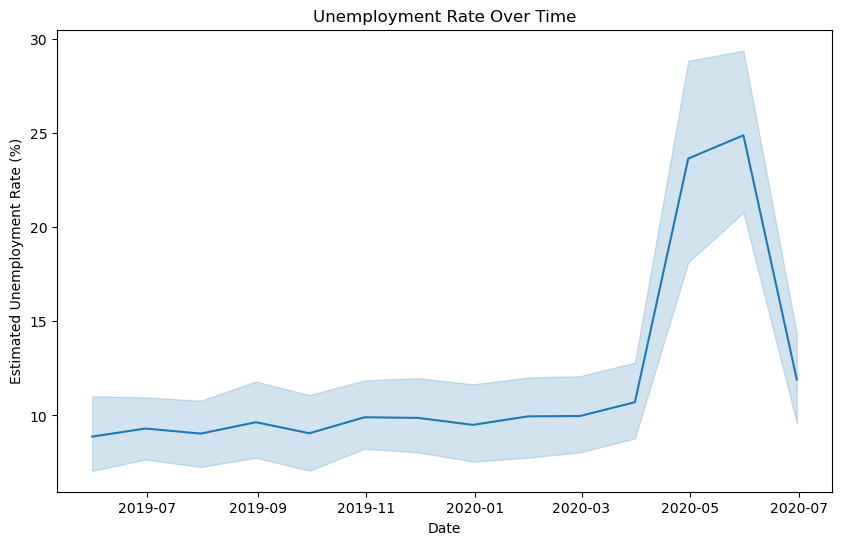

In [18]:
# Unemployment Trend Visualization

plt.figure(figsize=(10,6))
sns.lineplot(x='Date', y='Estimated Unemployment Rate (%)', data=df)
plt.title("Unemployment Rate Over Time")
plt.show()

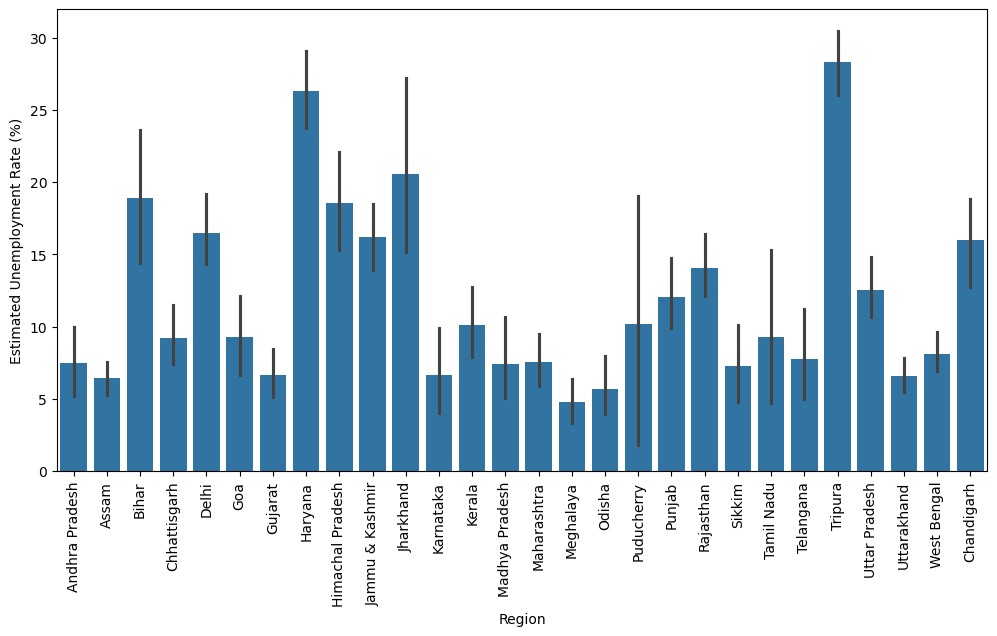

In [19]:
# Region Wise Unemployment

plt.figure(figsize=(12,6))
sns.barplot(x='Region', y='Estimated Unemployment Rate (%)', data=df)
plt.xticks(rotation=90)
plt.show()

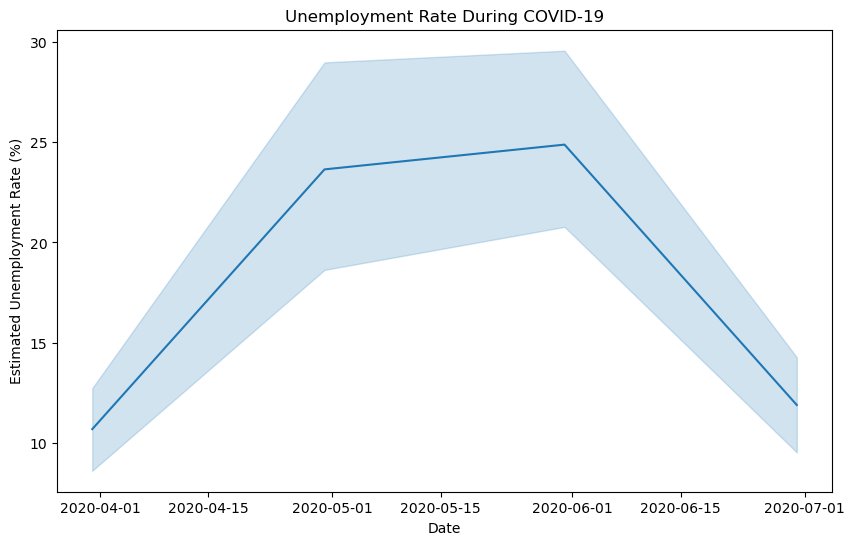

In [20]:
# COVID Spike Graph

plt.figure(figsize=(10,6))
sns.lineplot(x='Date', y='Estimated Unemployment Rate (%)', data=covid)
plt.title("Unemployment Rate During COVID-19")
plt.show()

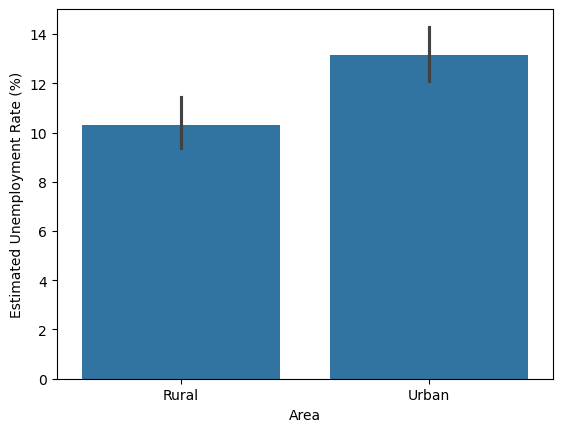

In [21]:
# Area-wise unemployment

sns.barplot(x='Area', y='Estimated Unemployment Rate (%)', data=df)
plt.show()

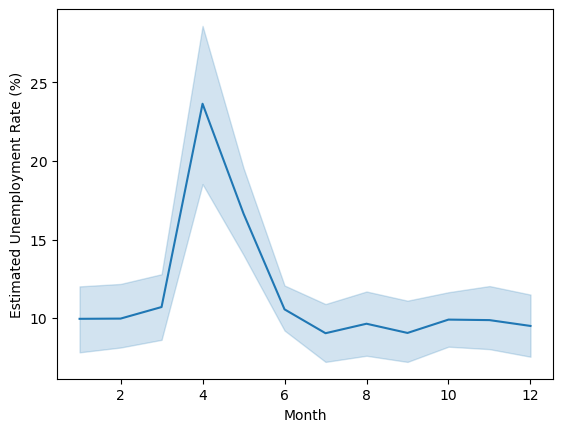

In [22]:
# Monthly unemployment trend

df['Month'] = df['Date'].dt.month

sns.lineplot(x='Month', y='Estimated Unemployment Rate (%)', data=df)
plt.show()

In [23]:
# Region comparison

df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values()

Region
Meghalaya            4.798889
Odisha               5.657857
Assam                6.428077
Uttarakhand          6.582963
Gujarat              6.663929
Karnataka            6.676071
Sikkim               7.249412
Madhya Pradesh       7.406429
Andhra Pradesh       7.477143
Maharashtra          7.557500
Telangana            7.737857
West Bengal          8.124643
Chhattisgarh         9.240357
Goa                  9.274167
Tamil Nadu           9.284286
Kerala              10.123929
Puducherry          10.215000
Punjab              12.031071
Uttar Pradesh       12.551429
Rajasthan           14.058214
Chandigarh          15.991667
Jammu & Kashmir     16.188571
Delhi               16.495357
Himachal Pradesh    18.540357
Bihar               18.918214
Jharkhand           20.585000
Haryana             26.283214
Tripura             28.350357
Name: Estimated Unemployment Rate (%), dtype: float64

# **Conclusion:**
The analysis shows that unemployment increased significantly during the COVID-19 period. The time-series trend clearly indicates a spike in unemployment during the pandemic months, highlighting the economic impact of COVID-19 across different regions.